In [20]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
load_dotenv()
print(os.getenv("OPENAI_API_KEY"))



sk-proj-2fx1Q13UZAmqRpPO4KYacA


In [27]:
model = ChatOpenAI( model="gpt-4o-mini", temperature=0.7, max_tokens=1000)

In [22]:
# create state

class LLMState(TypedDict):
    question: str
    answer: str

In [23]:
def llm_qa(state: LLMState) -> LLMState:
   #extract the question from the state
    question = state["question"]

    #form the prompt for the LLM
    prompt = f"Answer the following question: {question}"

    # ask the question to the LLM
    answer =model.invoke(prompt)

    #update the state with the answer
    state["answer"] = answer

    return state

In [24]:
#create our graph 
graph = StateGraph(LLMState)
#add Node 
graph.add_node("llm_qa",llm_qa)
#add edges

graph.add_edge(START, "llm_qa")
graph.add_edge("llm_qa", END)


#compile the graph
workflow = graph.compile()




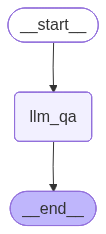

In [25]:
#how to see the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())  # Display the graph visualization


In [29]:
# execute the workflow
initial_state ={"question": "What is the capital of France?",}
result = workflow.invoke(initial_state)
print(result['answer'])


KeyboardInterrupt: 